# Mini-project 2: Conditional Variational auto-encoders (CVAEs)

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Introduction to auto-encoders, variational auto-encoders, and conditional variational auto-encoders.

### Auto-encoders
Auto-encoders (AE) are unsupervised learning models built on two architectural components that are trained together: The **encoder**, whose role is to reduce the dimension of the inputs through a funnel-shaped neural network, and the **decoder**, whose role is to turn the output of the encoder into an object with the same dimension as the encoder's input [1]. The objective of the learning procedure is that the data that enters the encoder should be similar to the data that exits the decoder. 

The state the data is found in between these two components is called the latent-state, and its role is to prevent overtraining of the model by forcing, through the reduction of dimension, a loss of information, so that the decoder cannot learn to exactly invert the transformations opperated by the encoder. Hence AEs can be seen as a generalization of principal component analysis (PCA), as the output of the encoder is a vector of smaller dimension, encoding the most vital information about the data. We can even note that AEs built on neural-networks with no activation functions are mathematically equivalent to PCA [1]. 


### Variational Auto-encoders
**Variational Auto-encoders** are unsupervised learning model with the same overall architecture, except that the latent space is no longer a vector space of smaller dimension, but a space of random variables [1] [2]. This latent space is often parametrized with $(\mu_i)_i$ and $\log(\Sigma)$, and the space of random distributions that can be learnt is reduced to the set of $\mathcal N_d(\mu,\sigma^2)$, where $\mu\in\mathbb R^d$ and $\Sigma$ is a matrix in $\mathbb R^n\times\mathbb R^n$. Thus in training, the VAE will learn how the distribution of the data can be encoded.

They also have another major plus compared to vanilla auto-encoders: given that in training the parameters for generating the data were learnt, the auto-encoder can now autonomosly generate data, as it only needs to simulate the random variable whose parameters were estimated in training. The VAE can even be trained with a supplementary KL-divergence term in the objective function, so that the latent representation of all individuals in the data resembles a realisation of a gaussian vextor. This makes the model better at data generation as the simulation of a gaussian vector would never land in a "void" of the latent space, as data decoded from voids in the latent space would generate bastardized data.

This can also then be used in data augmentation techniques, but also in image generation. However, this method does not allow us to generate specifically new data from a specific class.

### Conditional variational Auto-encoders
**Conditional variational Auto-encoders**

The idea behind this method is that, in classification tasks, data from different classes are generated from diferent random distributions, and therefore learning these distributions conditionally on the class the data was generated from is akin to learning how to classify the inputs. This is then no longer an unsupervised method [3]. After training then we could use the decoder as a conditional data generator.  

Some examples of Conditional variational auto-encoders exist on the web, but most of them make are built purely on neural-networks with no convolutions. [citations] This is fine whenever we are not interested in image generation, but it is a well known fact [1] vanilla neural-networks are very bad at preserving the locality of information necessary to handle images. 

There are however a few [4] that do use convolutions.

In this report we therefore create a few architectures of CVAEs with convolutional encoders and decoders.

## The idea in non-convolutional CVAE, and why we don't do it the same way for CVAEs

In this case, the idea is very simple. Take the architecture of a classical non-convolutional VAE, but concatenating to the input of the encoder the class label (with one-hot-encoding representation, for example). Similarly, in the decoder's input, concatenate to the latent vector the same label (with same representation, one-hot-encoding). This has been shown to work very efficiently. [3] + [citations] .

Conceptually, this approach would not be satisying for convolutional CVAEs.

## Architectures to be tested

We will test multiple architecures of convolutional CVAEs on the Fashion MNIST dataset, that containeds labeled images of different clothing accessories, imported below

In [3]:
from torchvision import datasets, transforms
batch_size = 128

# Data loading
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='../../data', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='../../data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

We will be choosing as a loss function a cross entropy function with a KL-divergence term.

In [4]:
def loss_function(recon_x, x, mu, logvar, beta=1):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD

### Concatenation of the label as a one-hot-encoded vector after the convolutional layer

In [ ]:

class ConditionalConvVAE_onehot_concatenation(nn.Module):
    def __init__(self, latent_dim=10):
        super(ConditionalConvVAE_onehot_concatenation, self).__init__()
        self.latent_dim = latent_dim
        self.nb_labels = 10

        # Convolutional layers of the encoder
        self.encoder_first_step = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # Output: (64, 7, 7)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

            
        self.linear = nn.Linear(128*4*4+self.nb_labels, 128*4*4+self.nb_labels)
        self.ReLU = nn.ReLU()
        
        # Fully connected layers for mean and log variance
        self.fc_mu = nn.Linear(self.nb_labels+128 * 4 * 4, latent_dim) 
        self.fc_logvar = nn.Linear(self.nb_labels+128 * 4 * 4, latent_dim) 
        self.fc_decode = nn.Linear(latent_dim + self.nb_labels, 128 * 4 * 4) 
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),  # Output: (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # Output: (1, 28, 28)
            nn.Sigmoid()
        )
    
    def encode(self, x, label):
        x = self.encoder_first_step(x) #The convolutive steps
        x = x.view(-1, 128 * 4 * 4)
        
        one_hot_list = torch.nn.functional.one_hot(torch.arange(0, self.nb_labels)).to(device)

        one_hot_label = one_hot_list[label,:]

        if one_hot_label.dim() == 1:  # single integer label
            one_hot_label = one_hot_label.unsqueeze(0).repeat(x.size(0), 1)

        x = torch.cat([x, one_hot_label],  dim=1) #Concatenation

        x = self.linear(x)
        
        #z = x_bis.view(-1, 1 + 128 * 4 * 4) # Flatten the output of the convolutional layers
        z = self.ReLU(x.view(-1, self.nb_labels + 128 * 4 * 4) )
        mu = self.fc_mu(z)
        logvar = self.fc_logvar(z)
        return mu, logvar
    

    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, label):
        one_hot_list = torch.nn.functional.one_hot(torch.arange(0, self.nb_labels)).to(device)
        
        one_hot_label = one_hot_list[label,:]

        if one_hot_label.dim() == 1:  # single integer label
            one_hot_label = one_hot_label.unsqueeze(0).repeat(z.size(0), 1)
        
        z = torch.cat([z, one_hot_label], dim=1)
        x = self.fc_decode(z)
        x = x.view(-1, 128, 4, 4)  # Reshape to (128, 4, 4) for the decoder
        x = self.decoder(x)
        return x

    def forward(self, x, label):
        mu, logvar = self.encode(x,label)
        z = self.sample(mu, logvar)
        return self.decode(z, label), mu, logvar


### Learning encodings of the labels (Paola's)

## Training these models

In [ ]:
# Train the model for the given number of epochs
# At the end of each epoch, print the training loss
def train_model(model, train_loader, test_loader,loss_function, optimizer , epochs, device):
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for batch_idx, (data, label) in enumerate(train_loader):
            #one_hot_list = torch.nn.functional.one_hot(torch.arange(0, model.nb_labels))#.to(device)
            
            #one_hot_label = one_hot_list[label,:]
            
            data = data.to(device)
            label = label.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logvar = model.forward(data, label)
            loss = loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch}, Training loss: {epoch_loss:.4f}')

We chose wich model we want to train

In [ ]:
# Hyperparameters
batch_size = 128
latent_dim = 2
learning_rate = 1e-3
epochs = 30
beta = 1

# Initialize the cvae model and the Adam optimizer
cvae = ConditionalConvVAE_onehot_concatenation(latent_dimbatch_size = 128=latent_dim)

#cvae=
#cvae=

cvae.to(device)
optimizer = optim.Adam(cvae.parameters(), lr=learning_rate)

Now we train the model

In [ ]:
train_model(model = cvae, train_loader=train_loader, loss_function=loss_function, optimizer=optimizer , epochs=epochs, device=device)

#train_model = 


Epoch 1, Training loss: 275.0296
Epoch 2, Training loss: 257.0218
Epoch 3, Training loss: 255.3971
Epoch 4, Training loss: 254.4678
Epoch 5, Training loss: 253.7348
Epoch 6, Training loss: 253.2554
Epoch 7, Training loss: 252.7809
Epoch 8, Training loss: 252.2958
Epoch 9, Training loss: 251.9756
Epoch 10, Training loss: 251.5867
Epoch 11, Training loss: 251.2785
Epoch 12, Training loss: 251.0489
Epoch 13, Training loss: 250.7360
Epoch 14, Training loss: 250.4030
Epoch 15, Training loss: 250.1810
Epoch 16, Training loss: 250.0219
Epoch 17, Training loss: 249.7968
Epoch 18, Training loss: 249.5641
Epoch 19, Training loss: 249.3661
Epoch 20, Training loss: 249.2392
Epoch 21, Training loss: 248.9818
Epoch 22, Training loss: 248.9051
Epoch 23, Training loss: 248.7570
Epoch 24, Training loss: 248.5890
Epoch 25, Training loss: 248.4619
Epoch 26, Training loss: 248.3395
Epoch 27, Training loss: 248.1344
Epoch 28, Training loss: 248.1016
Epoch 29, Training loss: 247.9202
Epoch 30, Training loss

## Visualizing

We can visualize how the trained model performs by seeing how much of the original image is preserved by the model

In [9]:

def image_comparison(original_images, reconstructions, n_images=6):
    """Plots the original images and its reconstructions for comparison

    Args:
        original_image (torch.Tensor): The original images
        reconstructions (torch.Tensor): Reconstruction of the original images
    """
    fig, ax = plt.subplots(2, n_images, figsize=(20, 7))
    
    for i in range(n_images):
        # Plot original images
        ax[0, i].imshow(original_images[i], cmap='gray')
        ax[0, i].axis('off')
        ax[0, 0].set_title('Original')

        
        # Reconstructed images
        ax[1, i].imshow(reconstructions[i], cmap='gray')
        ax[1, i].axis('off')
        ax[1, 0].set_title('Reconstruction')
    
    plt.tight_layout()
    plt.show()



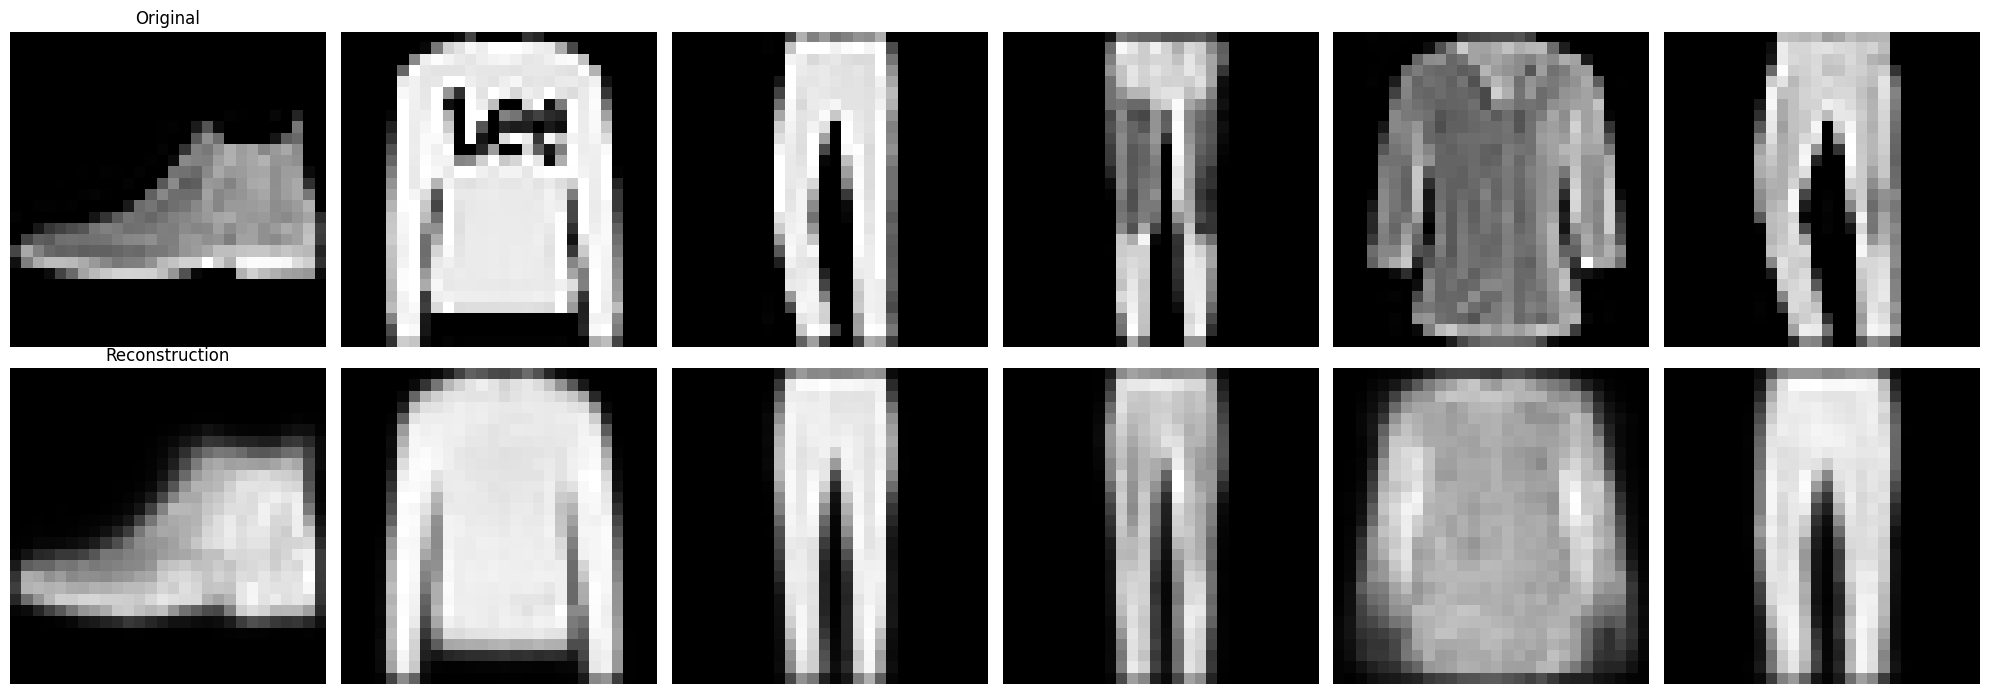

In [10]:
# Select a batch of images from the test dataset
random_images = next(iter(test_loader))

# Get the reconstructions of the selected images
recons, _, _ = cvae(random_images[0].to(device),random_images[1].to(device))

# Reshape the images for plotting
random_images = random_images[0].cpu().numpy().squeeze()
recons = recons.detach().cpu().numpy().squeeze()

# Plot the original images and their reconstructions
image_comparison(random_images, recons)

And we can also see that the models can infact generate images conditionally on the label we ask them to input

In [11]:
def generate_sample(label, num_samples=10):
    cvae.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)  # Sample latent vectors

        #image_1 = test_dataset[3][0]

        #mu, log_var= cvae.encode(image_1, label = 3)

        #z = cvae.sample(mu=mu, eps=torch.exp(log_var))
        
        samples = cvae.decode(z, label)
        samples = samples.cpu().view(num_samples, 1, 28, 28)  # Reshape

        fig, ax = plt.subplots(1, num_samples, figsize=(15, 2))
        if num_samples == 1:
            ax = [ax]  # Make it indexable

        for i in range(num_samples):
            ax[i].imshow(samples[i].squeeze(0), cmap='gray')
            ax[i].axis('off')
        plt.show()



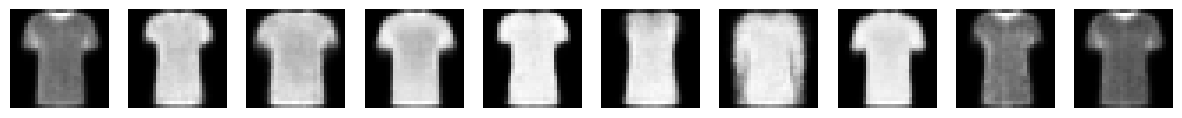

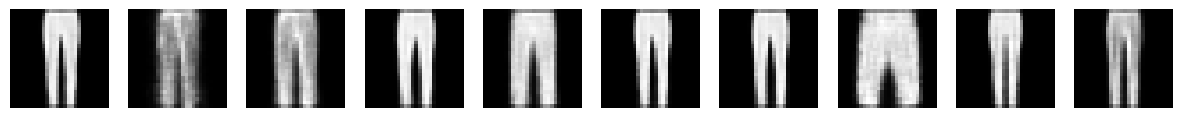

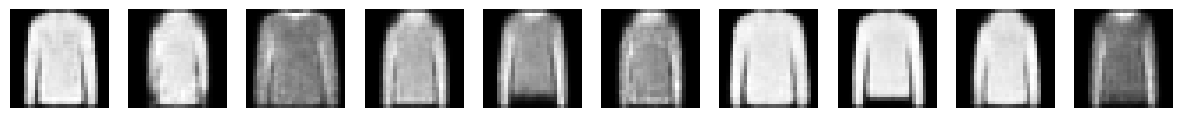

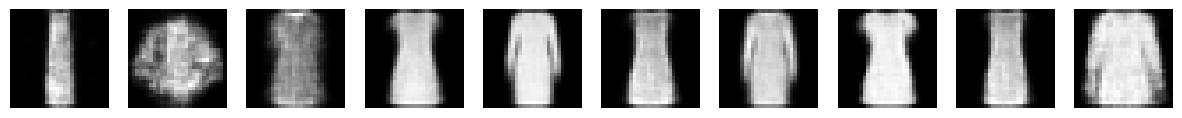

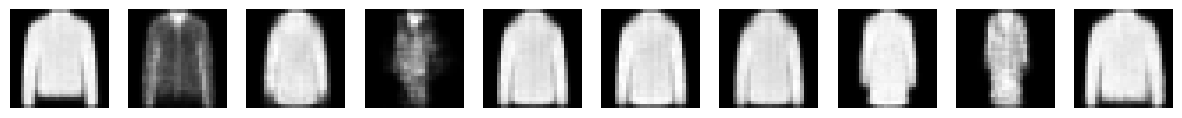

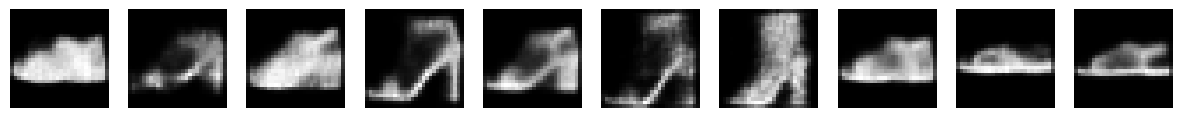

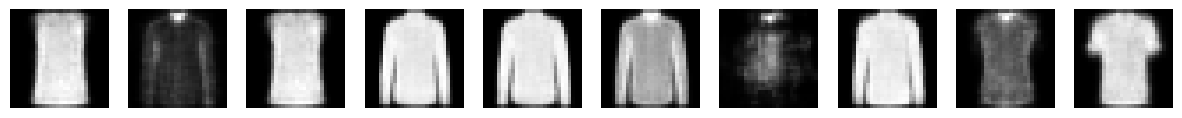

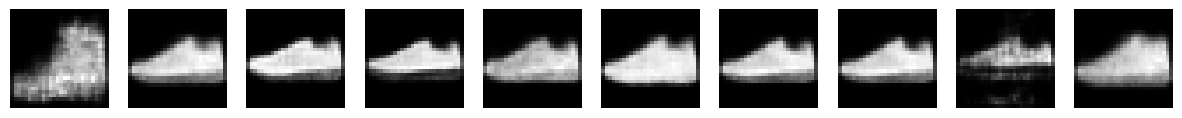

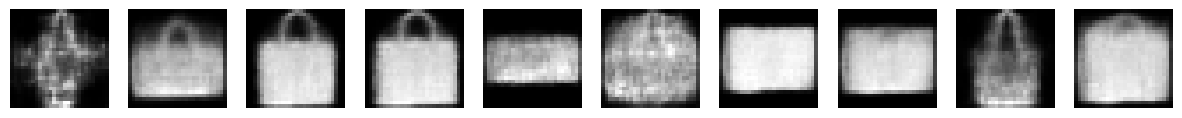

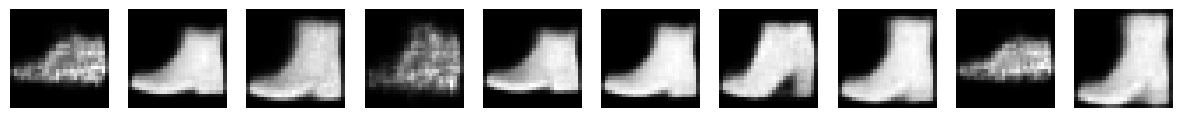

In [12]:
for i in range(0,10):
    generate_sample(label=i)

However, this is not a quantitative method for comparing the architectures

## Testing

In [13]:
import torch.nn.functional as F

def test_cvae(model, dataloader, device='cpu'):
    """
    Test a Conditional VAE model on a dataset.
    
    Args:
        model: instance of ConditionalConvVAE_int_concatenation
        dataloader: PyTorch DataLoader providing (images, labels)
        device: 'cpu' or 'cuda'
    
    Returns:
        avg_loss: average total VAE loss (reconstruction + KL)
        avg_recon_loss: average reconstruction loss
        avg_kl_loss: average KL divergence
    """
    model.eval()  # set model to evaluation mode
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    n_samples = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            batch_size = images.size(0)
            
            # Forward pass
            recon_images, mu, logvar = model(images, labels)
            
            # Reconstruction loss (use BCE if images are in [0,1], MSE otherwise)
            recon_loss = F.binary_cross_entropy(recon_images, images, reduction='sum')
            
            # KL divergence
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            
            # Total VAE loss
            loss = recon_loss + kl_loss
            
            # Accumulate
            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()
            n_samples += batch_size
    
    avg_loss = total_loss / n_samples
    avg_recon_loss = total_recon_loss / n_samples
    avg_kl_loss = total_kl_loss / n_samples
    
    print(f"Test Loss: {avg_loss:.4f}, Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}")
    
    return avg_loss, avg_recon_loss, avg_kl_loss


In [14]:
test_cvae(cvae, test_loader, device=device)

Test Loss: 250.6024, Recon Loss: 245.6781, KL Loss: 4.9242


(250.60236169433594, 245.67813720703126, 4.924223928833007)

# References


[1]: Joseba Dalmau, Juliette Chevalier and David Bertoin: High-dimensional and Deep Learning. Course for 5th year of engineering in applied mathematics, National Institute of Applied sciences of Toulouse (INSA Toulouse), 2025

[2]: DP Kingma, M Welling: Auto-Encoding Variational Bayes. arxiv preprint:1312.6114, 2013

[3] : DP Kingma, DJ Rezende, S Mohamed, M Welling: Semi-supervised Learning with Deep Generative Models. Advances in Neural Information Processing systems 2014

[4] : debtanu177. (2021). train_cvae.py [Computer software]. GitHub. https://github.com/debtanu177/CVAE_MNIST/blob/master/train_cvae.py